--- 3.1 PCA Experiment ---
Variance Ratio: 0.80 -> Components: 3
Variance Ratio: 0.90 -> Components: 4
Variance Ratio: 0.95 -> Components: 4
Variance Ratio: 0.99 -> Components: 5

--- 3.2 Clustering (GMM) ---


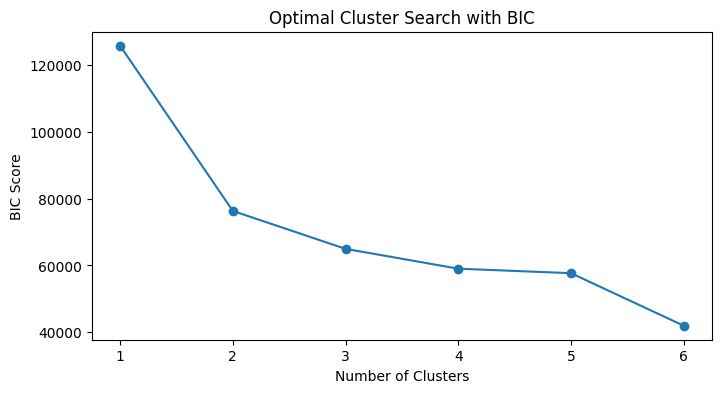


Final RMSE with GMM Feature: 1.0041


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from xgboost import XGBRegressor

# 1. データ読み込み
items = pd.read_csv('items.csv')
shops = pd.read_csv('shops.csv')
cats = pd.read_csv('item_categories.csv')
train = pd.read_csv('sales_train.csv')
test  = pd.read_csv('test.csv').set_index('ID')

# 2. 前処理（安全策：データが空にならないよう最小限に）
train = train[(train.item_price < 100000) & (train.item_cnt_day < 1001)]
train.loc[train.shop_id == 0, 'shop_id'] = 57
test.loc[test.shop_id == 0, 'shop_id'] = 57

shops['city_code'] = LabelEncoder().fit_transform(shops['shop_name'].str.split(' ').map(lambda x: x[0]))
cats['type_code'] = LabelEncoder().fit_transform(cats['item_category_name'].str.split('-').map(lambda x: x[0].strip()))

# 月間売上データの作成
matrix = []
for i in range(34):
    sales = train[train.date_block_num==i]
    if len(sales) > 0:
        matrix.append(np.array(list(product([i], sales.shop_id.unique(), sales.item_id.unique())), dtype='int16'))
matrix = pd.DataFrame(np.vstack(matrix), columns=['date_block_num','shop_id','item_id'])

group = train.groupby(['date_block_num','shop_id','item_id']).agg({'item_cnt_day': 'sum'})
group.columns = ['item_cnt_month']
matrix = pd.merge(matrix, group.reset_index(), on=['date_block_num','shop_id','item_id'], how='left').fillna(0)
matrix['item_cnt_month'] = matrix['item_cnt_month'].clip(0,20)

matrix = pd.merge(matrix, shops[['shop_id','city_code']], on=['shop_id'], how='left')
matrix = pd.merge(matrix, items.drop(['item_name'], axis=1), on=['item_id'], how='left')
matrix = pd.merge(matrix, cats[['item_category_id','type_code']], on=['item_category_id'], how='left')

# --- 3.1 PCA (主成分分析) 演習 ---
print("--- 3.1 PCA Experiment ---")
X_for_pca = matrix[matrix.date_block_num < 33].drop(['item_cnt_month'], axis=1)
X_scaled = StandardScaler().fit_transform(X_for_pca)

# 寄与率の変化を確認
for r in [0.80, 0.90, 0.95, 0.99]:
    pca = PCA(n_components=r).fit(X_scaled)
    print(f"Variance Ratio: {r:.2f} -> Components: {pca.n_components_}")

# --- 3.2 クラスタリング (GMM) 演習 ---
print("\n--- 3.2 Clustering (GMM) ---")
avg_price = train.groupby('item_id')['item_price'].mean().reset_index()
item_info = pd.merge(items, avg_price, on='item_id', how='left').fillna(0)
item_feat = StandardScaler().fit_transform(item_info[['item_price', 'item_category_id']])

# BIC/AICで最適クラスタ探索
n_range = np.arange(1, 7)
bics = [GaussianMixture(n, random_state=42).fit(item_feat).bic(item_feat) for n in n_range]

plt.figure(figsize=(8, 4))
plt.plot(n_range, bics, marker='o', label='BIC')
plt.title('Optimal Cluster Search with BIC')
plt.xlabel('Number of Clusters')
plt.ylabel('BIC Score')
plt.show()

# クラスタリング結果を特徴量として追加
best_n = n_range[np.argmin(bics)]
gmm = GaussianMixture(n_components=best_n, random_state=42)
item_info['item_cluster'] = gmm.fit_predict(item_feat)

# --- 4. 精度改善の確認 ---
matrix_final = pd.merge(matrix, item_info[['item_id', 'item_cluster']], on='item_id', how='left')

X_train = matrix_final[matrix_final.date_block_num < 33].drop(['item_cnt_month'], axis=1)
Y_train = matrix_final[matrix_final.date_block_num < 33]['item_cnt_month']
X_valid = matrix_final[matrix_final.date_block_num == 33].drop(['item_cnt_month'], axis=1)
Y_valid = matrix_final[matrix_final.date_block_num == 33]['item_cnt_month']

model = XGBRegressor(n_estimators=100, max_depth=8, random_state=42)
model.fit(X_train, Y_train)
rmse_final = np.sqrt(mean_squared_error(Y_valid, model.predict(X_valid)))
print(f'\nFinal RMSE with GMM Feature: {rmse_final:.4f}')